In [1]:
# 1. IMPORT LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
# 2. LOAD MNIST DATASET

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# 3. PREPROCESS DATA

# Normalize pixel values to range 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-length vectors
X_train = X_train.reshape(len(X_train), 784)
X_test = X_test.reshape(len(X_test), 784)

print("\nAfter Flattening:")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)

After Flattening:
Training Data Shape: (60000, 784)
Testing Data Shape: (10000, 784)


In [3]:
# 4. BUILD AUTOENCODER

input_dim = 784
encoding_dim = 32

# Input
inputs = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation="relu")(inputs)
x = Dense(64, activation="relu")(x)
encoded = Dense(encoding_dim, activation="relu")(x)

# Decoder
x = Dense(64, activation="relu")(encoded)
x = Dense(128, activation="relu")(x)
decoded = Dense(input_dim, activation="sigmoid")(x)

# Autoencoder and Encoder models
autoencoder = Model(inputs, decoded)
encoder = Model(inputs, encoded)

print("\nAUTOENCODER MODEL:")
autoencoder.summary()


AUTOENCODER MODEL:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 5. COMPILE MODEL

autoencoder.compile(optimizer="adam", loss="mse")

# 6. TRAIN MODEL

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=256,
    validation_split=0.10,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0671 - val_loss: 0.0400
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0328 - val_loss: 0.0274
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0248 - val_loss: 0.0228
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0213 - val_loss: 0.0200
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0192 - val_loss: 0.0181
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0175 - val_loss: 0.0167
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0163 - val_loss: 0.0157
Epoch 8/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0154 - val_loss: 0.0150
Epoch 9/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0147 - val_loss: 0.0143
Epoch 10/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0141 - val_loss: 0.0137
Epoch 11/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0135 - val_loss: 0.0133
Epoch 12/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

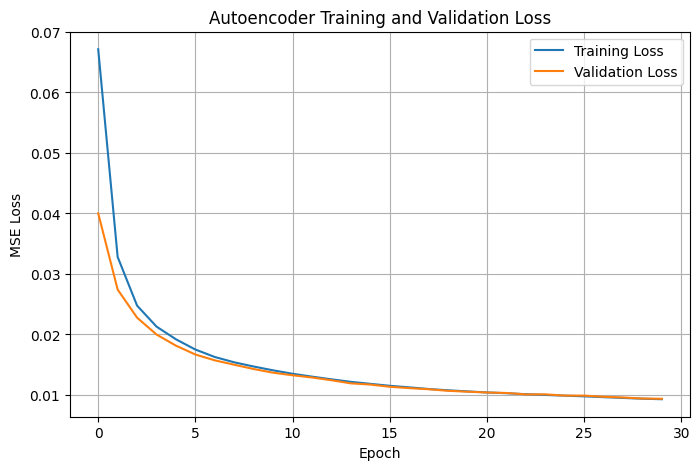

In [5]:
# 7. VISUALIZE TRAINING LOSS

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)
plt.show()

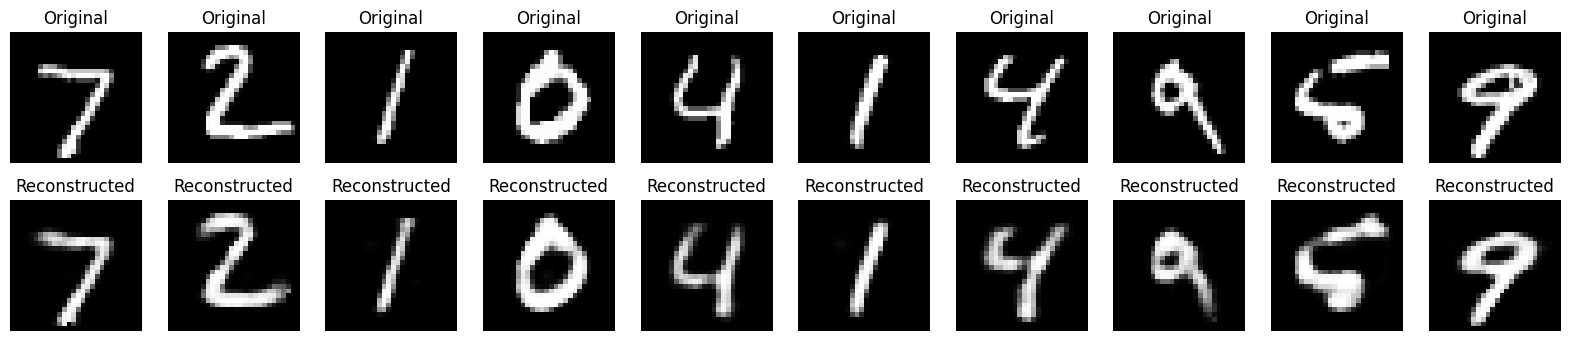

In [6]:
# 8. RECONSTRUCT TEST IMAGES

X_test_pred = autoencoder.predict(X_test, verbose=0)

# 9. DISPLAY ORIGINAL VS RECONSTRUCTED IMAGES

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):
    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_test_pred[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

In [7]:
# 10. EXTRACT REDUCED FEATURES (LATENT REPRESENTATION)

X_test_encoded = encoder.predict(X_test, verbose=0)

print("\nOriginal Feature Dimension:", X_test.shape[1])
print("Reduced Feature Dimension:", X_test_encoded.shape[1])
print("Compression Ratio:", round(X_test.shape[1] / X_test_encoded.shape[1], 2), ": 1")


Original Feature Dimension: 784
Reduced Feature Dimension: 32
Compression Ratio: 24.5 : 1


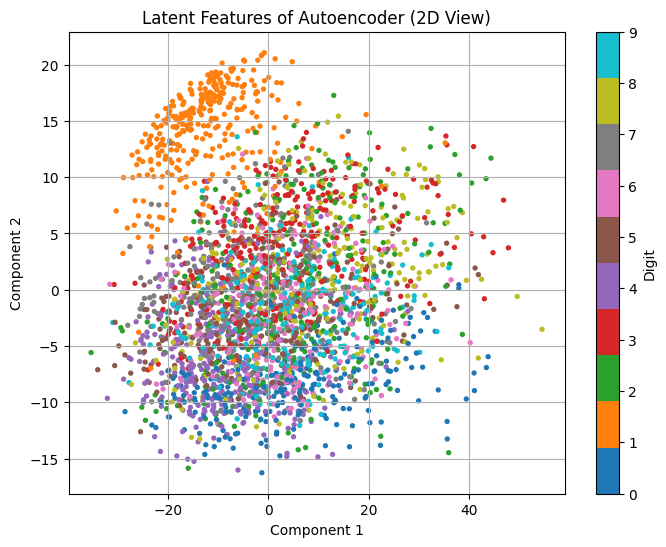

In [8]:
# 11. VISUALIZE REDUCED FEATURES IN 2D

# PCA is used only to display the 32 features in 2 dimensions
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(X_test_encoded[:3000])

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=y_test[:3000],
    cmap="tab10",
    s=8
)

plt.colorbar(scatter, label="Digit")
plt.title("Latent Features of Autoencoder (2D View)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

In [9]:
# 12. MODEL EVALUATION

mse = mean_squared_error(X_test.flatten(), X_test_pred.flatten())
mae = mean_absolute_error(X_test.flatten(), X_test_pred.flatten())
rmse = np.sqrt(mse)

# 13. DISPLAY FINAL RESULTS

print("\n===================================")
print("         MODEL EVALUATION")
print("===================================")

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

print("\n===================================")
print("          FINAL RESULT")
print("===================================")

print("Autoencoder trained successfully.")
print("Input Dimension:", input_dim)
print("Encoded Dimension:", encoding_dim)
print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))
print("Test MSE:", round(mse, 6))


         MODEL EVALUATION
Mean Squared Error (MSE): 0.009080191142857075
Mean Absolute Error (MAE): 0.03145561367273331
Root Mean Squared Error (RMSE): 0.09529003695485208

          FINAL RESULT
Autoencoder trained successfully.
Input Dimension: 784
Encoded Dimension: 32
Training Images: 60000
Testing Images: 10000
Test MSE: 0.00908
